# Comparative Analysis 
## The 0/1 Knapsack Problem 

This notebook executes a head-to-head comparative analysis between the Bat Algorithm (BA) and a Genetic Algorithm (GA) in solving the 0/1 Knapsack Problem. Because items can only be packed (1) or left behind (0), this problem evaluates the algorithms' ability to navigate strict **Binary Spaces** while maximizing value under severe weight constraints.

### 1. Configurations
All hyperparameters are centralized here to allow for rapid experimental tuning.

In [2]:

import math
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

# ---  GLOBAL EXPERIMENT SETTINGS ---
NUM_ITEMS = 50              # Number of items to generate
CAPACITY_RATIO = 0.3        # Knapsack can only hold 30% of total weight
POPULATION_SIZE = 100       # Swarm/Population size
MAX_GENERATIONS = 200       # Iterations for the main showdown

# ---  BAT ALGORITHM HYPERPARAMETERS ---
BA_A0 = 0.9                 # Initial Loudness
BA_R0 = 0.1                 # Initial Pulse Rate
BA_FMIN = 0.0               # Minimum Frequency
BA_FMAX = 2.0               # Maximum Frequency

# ---  GENETIC ALGORITHM HYPERPARAMETERS ---
GA_MUTATION_RATE = 0.1      # Probability of a bit-flip mutation

# ---  ROBUSTNESS TEST SETTINGS ---
TEST_RUNS = 10              # Number of independent runs
TEST_POPULATION = 50        # Smaller population for faster multi-runs
TEST_GENERATIONS = 150      # Fewer generations for faster multi-runs


### 2. The Environment and Objective Function
We generate a random dataset of items with specific weights and values. The objective function is strict **Maximization**, calculating the total $ value of the packed items. If the weight exceeds the knapsack's capacity, the algorithm applies a **Fatal Penalty**, returning a value of $0.

In [3]:
# DATASET GENERATION & OBJECTIVE FUNCTION
random.seed(42) 

item_weights = [random.randint(1, 20) for _ in range(NUM_ITEMS)]
item_values = [random.randint(10, 100) for _ in range(NUM_ITEMS)]
max_capacity = int(sum(item_weights) * CAPACITY_RATIO)

def calculate_knapsack_fitness(position, weights, values, capacity):
    """
    The Objective Function (Maximization).
    Calculates total value. If weight exceeds capacity, returns 0 (Fatal Penalty).
    """
    total_weight = sum(p * w for p, w in zip(position, weights))
    total_value = sum(p * v for p, v in zip(position, values))
    
    if total_weight > capacity:
        return 0.0 
    return float(total_value)
print(f"Total Items: {NUM_ITEMS} | Max Capacity: {max_capacity} kg")

Total Items: 50 | Max Capacity: 142 kg


### 3. The Discrete Math Engine (The Sigmoid Bridge)
The native Bat Algorithm calculates velocity as a continuous floating-point number. To force bats to make binary choices, we pass their velocity through a **Sigmoid Transfer Function**. A high positive momentum mathematically guarantees the bat will pack the item, while negative momentum guarantees it will drop it.

In [4]:

def sigmoid(x):
    """Squashes any continuous velocity into a probability between 0 and 1."""
    x = max(-700, min(700, x)) # Cap to prevent math overflow errors
    return 1 / (1 + math.exp(-x))

def update_binary_position(position, velocity):
    """Translates continuous velocity into a strict 1 (pack) or 0 (leave) decision."""
    new_position = []
    for i in range(len(velocity)):
        prob = sigmoid(velocity[i])
        if random.random() < prob:
            new_position.append(1)
        else:
            new_position.append(0)
    return new_position

### 4. The Binary Bat Agent
The agent maintains a continuous velocity tracker but operates strictly in a `[0, 1]` position array. The Local Search phase ("The Hunt") randomly flips the status of a single item to break out of overweight traps.

In [5]:
# THE BINARY BAT AGENT
class BinaryBat:
    def __init__(self, num_items):
        self.position = [random.choice([0, 1]) for _ in range(num_items)]
        self.velocity = [0.0 for _ in range(num_items)]
        self.fitness = 0.0
        self.A = BA_A0
        self.r = BA_R0
        self.r0 = BA_R0
        self.fmin = BA_FMIN
        self.fmax = BA_FMAX
        self.f = 0.0
        
    def update_frequency(self):
        self.f = self.fmin + (self.fmax - self.fmin) * random.random()

    def local_search(self, global_best_position):
        """The Hunt: Randomly flip the status of one item."""
        new_position = global_best_position.copy()
        idx_to_flip = random.randint(0, len(new_position) - 1)
        new_position[idx_to_flip] = 1 - new_position[idx_to_flip]
        return new_position
        
    def update_parameters(self, iteration, alpha=0.9, gamma=0.05):
        self.A = alpha * self.A
        self.r = self.r0 * (1 - math.exp(-gamma * iteration))

### 5. Bat Algorithm Execution
Because every random starting bag is mathematically likely to be overweight (and thus score $0), the `global_best_position` initializes as an empty bag to provide a safe mathematical anchor. The acceptance criteria demands a `>=` fitness evaluation to drive value maximization.

In [6]:

def ba_knapsack(weights, values, capacity, num_bats, max_iterations):
    num_items = len(weights)
    swarm = [BinaryBat(num_items) for _ in range(num_bats)]
    
    # Safe Init: Default to an empty bag so it's never 'None'
    global_best_position = [0] * num_items
    global_best_fitness = 0.0  
    logbook = []
    
    for bat in swarm:
        bat.fitness = calculate_knapsack_fitness(bat.position, weights, values, capacity)
        if bat.fitness > global_best_fitness:
            global_best_fitness = bat.fitness
            global_best_position = bat.position.copy()
            
    for t in range(max_iterations):
        gen_start_time = time.time()
        current_swarm_fitness = []
        
        for bat in swarm:
            bat.update_frequency()
            
            for j in range(num_items):
                bat.velocity[j] += (global_best_position[j] - bat.position[j]) * bat.f
                
            new_position = update_binary_position(bat.position, bat.velocity)
            
            if random.random() > bat.r:
                new_position = bat.local_search(global_best_position)
                
            new_fitness = calculate_knapsack_fitness(new_position, weights, values, capacity)
            
            # Accept if value is HIGHER or equal (Maximization)
            if new_fitness >= bat.fitness and random.random() < bat.A:
                bat.position = new_position.copy()
                bat.fitness = new_fitness
                bat.update_parameters(t)
                
            if bat.fitness > global_best_fitness:
                global_best_fitness = bat.fitness
                global_best_position = bat.position.copy()
                
            current_swarm_fitness.append(bat.fitness)

        gen_exec_time = time.time() - gen_start_time
        current_avg = sum(current_swarm_fitness) / num_bats
        
        logbook.append({
            "gen": t,
            "nevals": num_bats,
            "exec_time_seconds": round(gen_exec_time, 6),
            "max": global_best_fitness,
            "avg": round(current_avg, 3)
        })

    return global_best_position, global_best_fitness, pd.DataFrame(logbook)



### 6. Genetic Algorithm Baseline
The control group utilizes standard evolutionary operators adapted for binary arrays:
* **Uniform Crossover:** Randomly selects which parent provides the packing decision for each item.
* **Bit-flip Mutation:** Randomly flips 0s to 1s (and vice versa) to maintain genetic diversity.

In [7]:

def ga_knapsack(weights, values, capacity, pop_size, max_iterations):
    num_items = len(weights)
    population = [[random.choice([0, 1]) for _ in range(num_items)] for _ in range(pop_size)]
    
    # Safe Init
    global_best_position = [0] * num_items
    global_best_fitness = 0.0
    logbook = []

    for t in range(max_iterations):
        gen_start_time = time.time()
        
        pop_fitness = [(ind, calculate_knapsack_fitness(ind, weights, values, capacity)) for ind in population]
        # Sort DESCENDING because we want the highest value at index 0
        pop_fitness.sort(key=lambda x: x[1], reverse=True)
        
        current_max = pop_fitness[0][1]
        current_avg = sum(f for _, f in pop_fitness) / pop_size
        
        if current_max >= global_best_fitness:
            global_best_fitness = current_max
            global_best_position = pop_fitness[0][0].copy()
            
        next_gen = [pop_fitness[0][0], pop_fitness[1][0]] # Elitism
        
        while len(next_gen) < pop_size:
            # Tournament Selection
            p1 = max(random.sample(pop_fitness, 3), key=lambda x: x[1])[0]
            p2 = max(random.sample(pop_fitness, 3), key=lambda x: x[1])[0]
            
            # Uniform Crossover
            child = [p1[i] if random.random() < 0.5 else p2[i] for i in range(num_items)]
            
            # Bit-flip Mutation
            for i in range(num_items):
                if random.random() < GA_MUTATION_RATE:
                    child[i] = 1 - child[i]
                    
            next_gen.append(child)
            
        population = next_gen
        gen_exec_time = time.time() - gen_start_time
        
        logbook.append({
            "gen": t,
            "nevals": pop_size,
            "exec_time_seconds": round(gen_exec_time, 6),
            "max": current_max,
            "avg": round(current_avg, 3)
        })

    return global_best_position, global_best_fitness, pd.DataFrame(logbook)

### 7. Statistical Showdown and Strategy Visualization
Both algorithms are executed under identical conditions. The outcomes are compared via execution time, convergence speed, and a direct visual rendering of the algorithms' final packing strategies.

0/1 Knapsack (Pop: 100, Gen: 200)...

  BAT ALGORITHM RESULTS==
0 - Best fitness: 1087 - Avg Fitness: 352.5500 - Time: 0.0066s
1 - Best fitness: 1087 - Avg Fitness: 541.1100 - Time: 0.0050s
2 - Best fitness: 1087 - Avg Fitness: 660.3900 - Time: 0.0050s
3 - Best fitness: 1087 - Avg Fitness: 704.6200 - Time: 0.0070s
4 - Best fitness: 1087 - Avg Fitness: 763.2000 - Time: 0.0060s
5 - Best fitness: 1087 - Avg Fitness: 803.6500 - Time: 0.0055s
6 - Best fitness: 1087 - Avg Fitness: 876.0900 - Time: 0.0060s
7 - Best fitness: 1087 - Avg Fitness: 905.5000 - Time: 0.0060s
8 - Best fitness: 1087 - Avg Fitness: 931.0600 - Time: 0.0050s
9 - Best fitness: 1087 - Avg Fitness: 953.5900 - Time: 0.0060s
10 - Best fitness: 1087 - Avg Fitness: 965.5900 - Time: 0.0060s
11 - Best fitness: 1087 - Avg Fitness: 967.3300 - Time: 0.0070s
12 - Best fitness: 1087 - Avg Fitness: 999.4400 - Time: 0.0050s
13 - Best fitness: 1087 - Avg Fitness: 1012.0300 - Time: 0.0051s
14 - Best fitness: 1087 - Avg Fitness: 1013.1300 

<Figure size 1600x1200 with 0 Axes>

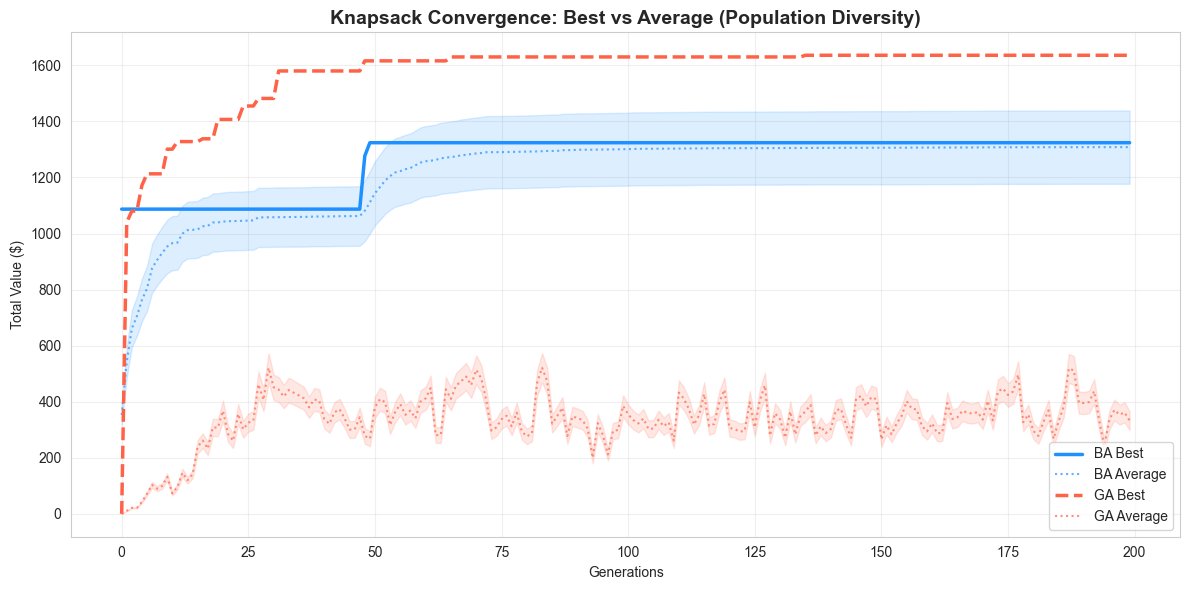

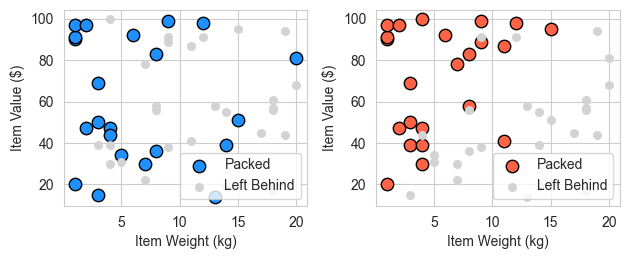

In [8]:

print(f"0/1 Knapsack (Pop: {POPULATION_SIZE}, Gen: {MAX_GENERATIONS})...\n")

ba_pos, ba_fit, ba_log = ba_knapsack(item_weights, item_values, max_capacity, POPULATION_SIZE, MAX_GENERATIONS)
ga_pos, ga_fit, ga_log = ga_knapsack(item_weights, item_values, max_capacity, POPULATION_SIZE, MAX_GENERATIONS)

ba_weight_used = sum(p * w for p, w in zip(ba_pos, item_weights))
ga_weight_used = sum(p * w for p, w in zip(ga_pos, item_weights))

print("  BAT ALGORITHM RESULTS==")
for index, row in ba_log.head(15).iterrows():
    print(f"{int(row['gen'])} - Best fitness: {int(row['max'])} - Avg Fitness: {row['avg']:.4f} - Time: {row['exec_time_seconds']:.4f}s")
print(f"\nBest solution:\n0 :  {float(ba_fit)}  ->  Individual('i', {ba_pos})\n")

print("GENETIC ALGORITHM RESULTS==")
for index, row in ga_log.head(15).iterrows():
    print(f"{int(row['gen'])} - Best fitness: {int(row['max'])} - Avg Fitness: {row['avg']:.4f} - Time: {row['exec_time_seconds']:.4f}s")
print(f"\nBest solution:\n0 :  {float(ga_fit)}  ->  Individual('i', {ga_pos})\n\n")

table_data = [
    ["Algorithm", "Pop", "Gen", "Weight Used (kg)", "Final Max Value ($)", "Final Avg Value ($)", "Total Time (s)", "Avg Gen Time (s)"],
    ["Bat Algorithm", POPULATION_SIZE, MAX_GENERATIONS, f"{ba_weight_used}/{max_capacity}", f"${ba_fit:.0f}", f"${ba_log['avg'].iloc[-1]:.2f}", f"{ba_log['exec_time_seconds'].sum():.4f}", f"{ba_log['exec_time_seconds'].mean():.6f}"],
    ["Genetic Algorithm", POPULATION_SIZE, MAX_GENERATIONS, f"{ga_weight_used}/{max_capacity}", f"${ga_fit:.0f}", f"${ga_log['avg'].iloc[-1]:.2f}", f"{ga_log['exec_time_seconds'].sum():.4f}", f"{ga_log['exec_time_seconds'].mean():.6f}"]
]
print("--- ALGORITHM PERFORMANCE SUMMARY ---")
print(tabulate(table_data, headers='firstrow', tablefmt='fancy_grid'))
print("\n")

# ---  CONVERGENCE ---
sns.set_style("whitegrid") 
fig = plt.figure(figsize=(16, 12))


plt.figure(figsize=(12, 6))

ax = plt.gca()
ax.plot(ba_log['gen'], ba_log['max'], color='dodgerblue', linewidth=2.5, label='BA Best')
ax.plot(ba_log['gen'], ba_log['avg'], color='dodgerblue', linestyle=':', alpha=0.7, label='BA Average')
ax.fill_between(ba_log['gen'], 
                ba_log['avg'] - ba_log['std'] if 'std' in ba_log.columns else ba_log['avg']*0.9,
                ba_log['avg'] + ba_log['std'] if 'std' in ba_log.columns else ba_log['avg']*1.1,
                color='dodgerblue', alpha=0.15)

# GA: Same
ax.plot(ga_log['gen'], ga_log['max'], color='tomato', linewidth=2.5, linestyle='--', label='GA Best')
ax.plot(ga_log['gen'], ga_log['avg'], color='tomato', linestyle=':', alpha=0.7, label='GA Average')
ax.fill_between(ga_log['gen'],
                ga_log['avg'] - ga_log['std'] if 'std' in ga_log.columns else ga_log['avg']*0.9,
                ga_log['avg'] + ga_log['std'] if 'std' in ga_log.columns else ga_log['avg']*1.1,
                color='tomato', alpha=0.15)

ax.set_title("Knapsack Convergence: Best vs Average (Population Diversity)", fontsize=14, fontweight='bold')
ax.set_xlabel("Generations")
ax.set_ylabel("Total Value ($)")
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('knapsack_convergence_diversity.png', dpi=300, bbox_inches='tight')
plt.show()

# Bottom Graphs: Strategy Scatter Plots
def draw_scatter(ax, pos, title, line_color):
    packed_w, packed_v, left_w, left_v = [], [], [], []
    for i in range(len(pos)):
        if pos[i] == 1:
            packed_w.append(item_weights[i])
            packed_v.append(item_values[i])
        else:
            left_w.append(item_weights[i])
            left_v.append(item_values[i])
   
    ax.scatter(packed_w, packed_v, c=line_color, s=80, edgecolors='black', label='Packed')
    ax.scatter(left_w, left_v, c='lightgray', s=30, label='Left Behind')
    ax.set_xlabel("Item Weight (kg)")
    ax.set_ylabel("Item Value ($)")
    ax.legend()

ax2 = plt.subplot(2, 2, 3)
draw_scatter(ax2, ba_pos, f"BA Strategy (Packed: {sum(ba_pos)} items)", 'dodgerblue')
ax3 = plt.subplot(2, 2, 4)
draw_scatter(ax3, ga_pos, f"GA Strategy (Packed: {sum(ga_pos)} items)", 'tomato')

plt.tight_layout()
plt.show()

### 8. Stochastic Robustness Test
Because metaheuristics rely on random number generation, a single execution is statistically insufficient. This cell executes 10 independent runs of both algorithms to evaluate their variance, reliability, and worst-case performance bounds.

---  ROBUSTNESS TEST (10 Independent Runs) ---
Using reduced parameters for speed (Pop: 50, Gen: 150)...

Executing Run 1/10...
Executing Run 2/10...
Executing Run 3/10...
Executing Run 4/10...
Executing Run 5/10...
Executing Run 6/10...
Executing Run 7/10...
Executing Run 8/10...
Executing Run 9/10...
Executing Run 10/10...

Processing statistics...

╒═══════════════════╤══════════════════════╤═══════════════════════╤═════════════════════╤═════════════════╕
│ Algorithm         │ Best Bag Found ($)   │ Worst Bag Found ($)   │ Average Value ($)   │   Std Deviation │
╞═══════════════════╪══════════════════════╪═══════════════════════╪═════════════════════╪═════════════════╡
│ Bat Algorithm     │ $1491.00             │ $1115.00              │ $1309.40            │          130.56 │
├───────────────────┼──────────────────────┼───────────────────────┼─────────────────────┼─────────────────┤
│ Genetic Algorithm │ $1695.00             │ $1607.00              │ $1651.60            │           

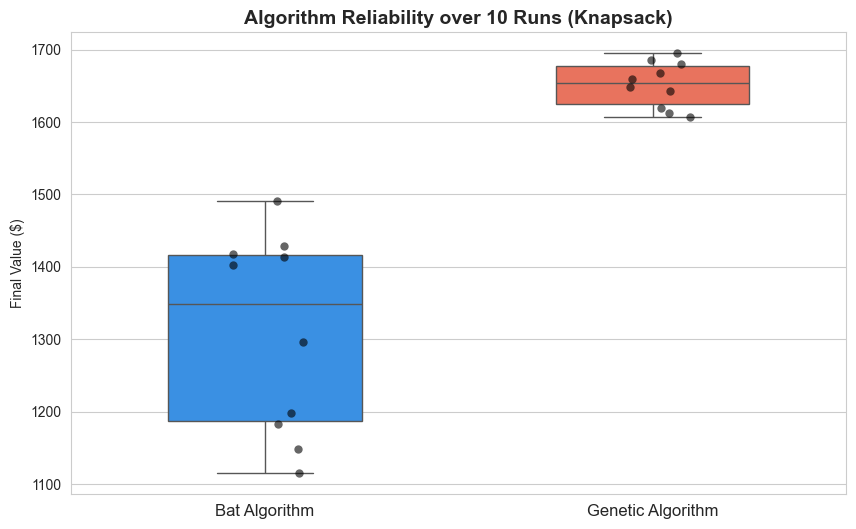

In [9]:

print(f"---  ROBUSTNESS TEST ({TEST_RUNS} Independent Runs) ---")
print(f"Using reduced parameters for speed (Pop: {TEST_POPULATION}, Gen: {TEST_GENERATIONS})...\n")

ba_final_vals, ga_final_vals = [], []

for i in range(TEST_RUNS):
    print(f"Executing Run {i+1}/{TEST_RUNS}...")
    _, ba_fit, _ = ba_knapsack(item_weights, item_values, max_capacity, TEST_POPULATION, TEST_GENERATIONS)
    _, ga_fit, _ = ga_knapsack(item_weights, item_values, max_capacity, TEST_POPULATION, TEST_GENERATIONS)
    ba_final_vals.append(ba_fit)
    ga_final_vals.append(ga_fit)

print("\nProcessing statistics...\n")

table_data = [
    ["Algorithm", "Best Bag Found ($)", "Worst Bag Found ($)", "Average Value ($)", "Std Deviation"],
    ["Bat Algorithm", f"${np.max(ba_final_vals):.2f}", f"${np.min(ba_final_vals):.2f}", f"${np.mean(ba_final_vals):.2f}", f"{np.std(ba_final_vals):.2f}"],
    ["Genetic Algorithm", f"${np.max(ga_final_vals):.2f}", f"${np.min(ga_final_vals):.2f}", f"${np.mean(ga_final_vals):.2f}", f"{np.std(ga_final_vals):.2f}"]
]
print(tabulate(table_data, headers='firstrow', tablefmt='fancy_grid'))

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
# We flip the data order so the higher numbers are at the top, since this is maximization
sns.boxplot(data=[ba_final_vals, ga_final_vals], palette=['dodgerblue', 'tomato'], width=0.5)
sns.stripplot(data=[ba_final_vals, ga_final_vals], color='black', alpha=0.6, jitter=True, size=6)
plt.title(f"Algorithm Reliability over {TEST_RUNS} Runs (Knapsack)", fontsize=14, fontweight='bold')
plt.ylabel("Final Value ($)")
plt.xticks([0, 1], ['Bat Algorithm', 'Genetic Algorithm'], fontsize=12)
plt.show()

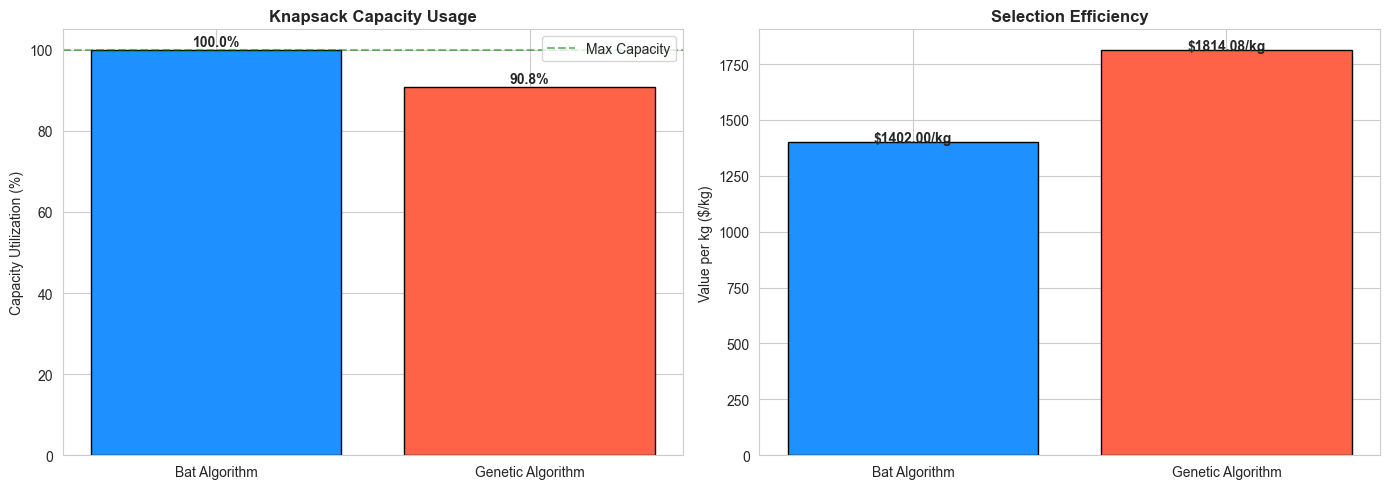

In [10]:

import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Capacity Used (%)
capacity_used_ba = sum(p * w for p, w in zip(ba_pos, item_weights)) / max_capacity * 100
capacity_used_ga = sum(p * w for p, w in zip(ga_pos, item_weights)) / max_capacity * 100

bars = ax1.bar(['Bat Algorithm', 'Genetic Algorithm'], 
               [capacity_used_ba, capacity_used_ga],
               color=['dodgerblue', 'tomato'], edgecolor='black')
ax1.set_ylabel('Capacity Utilization (%)')
ax1.set_title('Knapsack Capacity Usage', fontweight='bold')
ax1.axhline(y=100, color='green', linestyle='--', alpha=0.5, label='Max Capacity')
ax1.legend()
for bar, val in zip(bars, [capacity_used_ba, capacity_used_ga]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{val:.1f}%', ha='center', fontweight='bold')

# Chart 2: Value per kg (Efficiency)
ba_efficiency = ba_fit / capacity_used_ba * 100 if capacity_used_ba > 0 else 0
ga_efficiency = ga_fit / capacity_used_ga * 100 if capacity_used_ga > 0 else 0

ax2.bar(['Bat Algorithm', 'Genetic Algorithm'], 
        [ba_efficiency, ga_efficiency],
        color=['dodgerblue', 'tomato'], edgecolor='black')
ax2.set_ylabel('Value per kg ($/kg)')
ax2.set_title('Selection Efficiency', fontweight='bold')
for bar, val in zip(ax2.patches, [ba_efficiency, ga_efficiency]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'${val:.2f}/kg', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('knapsack_efficiency.png', dpi=300, bbox_inches='tight')
plt.show()